In [1]:
import random
from pathlib import Path
from collections import defaultdict
import itertools as it
import os
from datetime import datetime

import pandas as pd
import numpy as np
from scipy import stats
from supabase import create_client, Client
from dotenv import load_dotenv
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import seaborn as sns
from conjugate_normal import conjugate_normal
load_dotenv()

url = os.getenv('SUPABASE_URL')
key = os.getenv('SUPABASE_KEY')
supabase = create_client(supabase_url=url, supabase_key=key)

In [5]:
response = (
    supabase.table("logs")
    .select("*")
    # .gt("created_at", ["2025-06-09 22:44:42.376757+00"])
    .eq("client_name", "cs_gatech_summer_2025")
    .eq("api_endpoint", "/score/summary/stairs")
    .execute()
)
data = response.data

In [6]:
df1 = pd.DataFrame(data)
df2 = pd.json_normalize(df1["request_body"], sep="_")
df3 = pd.json_normalize(df1["response_body"], sep="_")
df = pd.concat([
    df1,
    df2,
    df3
], axis=1)
# Drop columns that start with "focus_time"
df = df.loc[:, ~df.columns.str.startswith('focus_time')]
# Select rows with class_id == "hinze_class"
# df = df.query("class_id == 'hinze_class'")

df = df.dropna(subset=["metrics_content_score"])
df['created_at'] = pd.to_datetime(df['created_at'])
df = df.sort_values('created_at')
with pd.option_context('display.max_columns', None): 
    display(df)

,id,created_at,api_endpoint,request_method,status_code,client_name,request_body,response_body,ttft,process_time,summary,class_id,page_slug,chat_history,score_history,excluded_chunks,prompt,is_passed,metrics_content_name,metrics_content_score,metrics_content_feedback,metrics_content_is_passed,metrics_content_threshold,metrics_english_name,metrics_english_score,metrics_english_feedback,metrics_english_is_passed,metrics_english_threshold,metrics_profanity_name,metrics_profanity_score,metrics_profanity_feedback,metrics_profanity_is_passed,metrics_profanity_threshold,metrics_similarity_name,metrics_similarity_score,metrics_similarity_feedback,metrics_similarity_is_passed,metrics_similarity_threshold,metrics_containment_name,metrics_containment_score,metrics_containment_feedback,metrics_containment_is_passed,metrics_containment_threshold,metrics_containment_chat_name,metrics_containment_chat_score,metrics_containment_chat_feedback,metrics_containment_chat_is_passed,metrics_containment_chat_threshold,text,chunk,request_id,question_type
6,26957,2025-06-02 18:01:17.116356+00:00,/score/summary/stairs,POST,200,cs_gatech_summer_2025,"{'summary': 'In this article of unit 4, the ar...",{'prompt': 'Excellent job summarizing the text...,NaN,5.813609,"In this article of unit 4, the article goes in...",joyner_class,4-1-data-structures,[],"[0.170596644282341, 0.0777144655585289, 0.3498...","[Advanced-Data-Types-3108, Terminology-By-Refe...",Excellent job summarizing the text. Please mov...,True,Content,0.389820,You did a good job of including key ideas and ...,True,-0.112630,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,Relevance,0.590768,You did a good job of staying on topic and wri...,True,0.5,Language Borrowing,0.0303,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
7,26990,2025-06-02 18:17:26.543553+00:00,/score/summary/stairs,POST,200,cs_gatech_summer_2025,{'summary': 'In this article on 4.3 lists for ...,{'prompt': 'Excellent job summarizing the text...,NaN,6.897407,"In this article on 4.3 lists for the unit 4, t...",joyner_class,4-3-lists,[],"[0.170596644282341, 0.0777144655585289, 0.3498...","[List-Synonyms-3175, Usefulness-of-Tuples-3178...",Excellent job summarizing the text. Please mov...,True,Content,0.153598,You did a good job of including key ideas and ...,True,-0.092408,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,Relevance,0.746539,You did a good job of staying on topic and wri...,True,0.5,Language Borrowing,0.0435,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
8,27003,2025-06-02 18:30:30.447676+00:00,/score/summary/stairs,POST,200,cs_gatech_summer_2025,"{'summary': 'In this article of unit 4, the ar...",{'prompt': 'Excellent job summarizing the text...,NaN,7.508686,"In this article of unit 4, the article talks a...",joyner_class,4-5-dictionaries,[],"[0.170596644282341, 0.0777144655585289, 0.3498...","[Creating-and-Accessing-Dictionaries-3241, Dic...",Excellent job summarizing the text. Please mov...,True,Content,0.055259,You did a good job of including key ideas and ...,True,-0.109945,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,Relevance,0.622758,You did a good job of staying on topic and wri...,True,0.5,Language Borrowing,0.0000,You did a good job of using your own language ...,True,0.6,Language Borrowing (from iTELL AI),NaN,None,None,0.6,NaN,NaN,NaN,NaN
11,27328,2025-06-05 20:56:23.052887+00:00,/score/summary/stairs,POST,200,cs_gatech_summer_2025,{'summary': 'This page is all about control st...,{'prompt': 'Excellent job summarizing the text...,NaN,8.153806,"This page is all about control structures, fro...",joyner_class,3-1-control-structures,[],[],[Indentation-and-Conditionals-2870],Excellent job summarizing the text. Please mov...,True,Content,0.546196,You did a good job of including key ideas and ...,True,-0.010038,English,1.0,,True,1.0,Profanity,0.0,,True,0.0,R

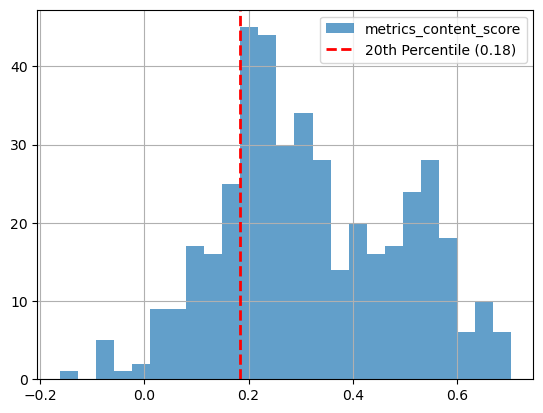

In [7]:
df["metrics_content_score"].hist(legend=True, bins=25, alpha=0.7);

# Calculate and add the 20th percentile line
percentile_20 = df["metrics_content_score"].quantile(0.2)
plt.axvline(percentile_20, color='red', linestyle='--', linewidth=2, label=f"20th Percentile ({percentile_20:.2f})")

# Add legend and show
plt.legend()
plt.show()

In [8]:
df.metrics_content_threshold.mean()

0.20412584399869507

## Simulating the Bayesian Score Distributions

If we had used a Bayesian approach to estimate the scoring distribution over time during these deployments...

In [107]:
mu_global = 0.8
k_global = 1
alpha_global = 4
beta_global = 1

target_threshold = 0.25
k_volume = 3
scaling_factor = .5

In [108]:
volumes = {}
volume_updates = []
submission_thresholds = []

volume = conjugate_normal(mu_global, k_global, alpha_global, beta_global, percentile=target_threshold)
start_threshold = volume.threshold

student_score_history = defaultdict(list)

for i, row in enumerate(df.itertuples()):
    # Create temporary volume prior from volume prior information
    scaled_beta = volume.beta * scaling_factor
    student_dist = conjugate_normal(volume.mu, k_volume, volume.alpha, scaled_beta, percentile=target_threshold)

    # Update temporary volume prior with score history
    if row.score_history:
        student_dist.update(row.score_history)
        submission_thresholds.append(student_dist.threshold)
    else:
        submission_thresholds.append(volume.threshold)

    # Update Volume
    if not np.isnan(row.metrics_content_score):
        # Update Volume Prior
        # volume.update([row.metrics_content_score], increment_k=True)
        if volume.k > 15:
            volume.update([row.metrics_content_score], increment_k=False)
        else:
            volume.update([row.metrics_content_score], increment_k=True)

    volume_updates.append((volume.mu, volume.sigma, volume.threshold))
    
df["bayesian_threshold"] = submission_thresholds

,Observed,Simulated Bayesian Personalized,Simulated Bayesian Volume Prior Only,20th Percentile
0,0.75,0.47,0.8,0.76


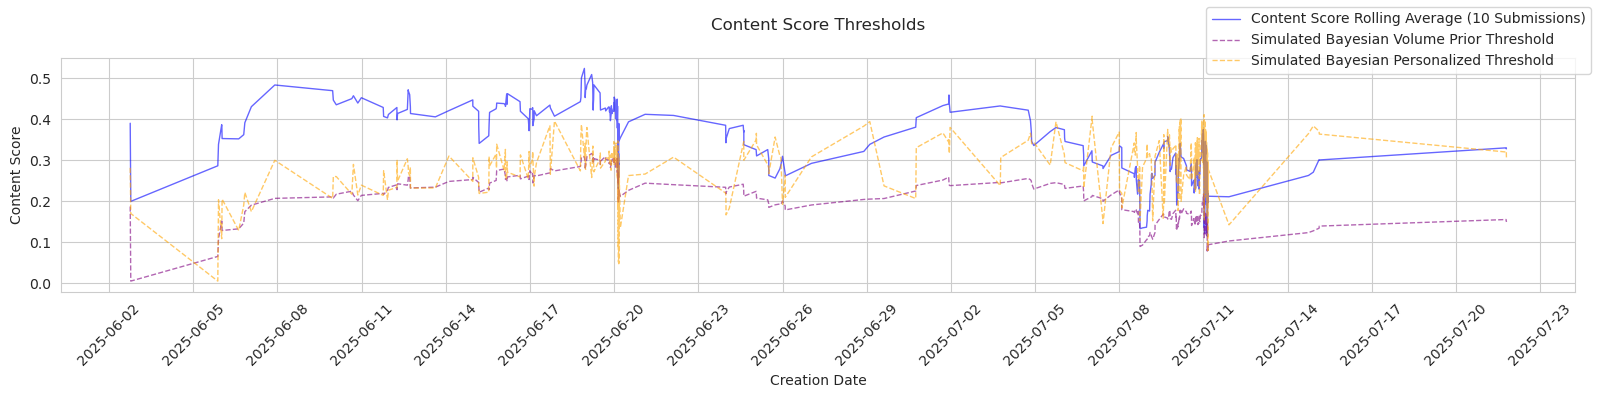

In [109]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(1, figsize=(16, 4))

pass_rates = []

# Calculate and plot rolling average (10 submissions)
rolling_avg = df['metrics_content_score'].rolling(window=10, min_periods=1).mean()
sns.lineplot(ax=ax, x=df["created_at"], y=rolling_avg, 
             label='Content Score Rolling Average (10 Submissions)', legend=False,
             color='blue', linewidth=1, alpha=0.6)

# Draw Observed Threshold (as the student experienced it)
# sns.lineplot(ax=ax, data=df, x='created_at', y='metrics_content_threshold', 
#              label='Observed Threshold in Production', legend=False,
#              color='green', linewidth=1, alpha=0.6, linestyle='dashed')

# Draw Volume Prior
updates_array = np.array(volume_updates)
sns.lineplot(ax=ax, x=df['created_at'], y=updates_array[:,2], 
             label='Simulated Bayesian Volume Prior Threshold', legend=False,
             color='purple', linewidth=1, alpha=0.6, linestyle='dashed')

# Draw Bayesian Threshold
sns.lineplot(ax=ax, data=df, x='created_at', y='bayesian_threshold', 
             label='Simulated Bayesian Personalized Threshold', legend=False,
             color='orange', linewidth=1, alpha=0.6, linestyle='dashed')

# Manually set the threshold for the first window_size samples
# Since we don't have enough data to calculate a fair rolling averagewindow_size = 10
window_size=10
rolling_20th = df["metrics_content_score"].rolling(window=window_size, min_periods=1, closed='left').quantile(0.2)
rolling_20th.iloc[:window_size] = 0.0

# Print Pass Rates
pass_rates.append({
    "Observed": (df["metrics_content_score"] > df["metrics_content_threshold"]).astype(int).mean(),
    "Simulated Bayesian Personalized": (df["metrics_content_score"] > df["bayesian_threshold"]).astype(int).mean(),
    "Simulated Bayesian Volume Prior Only": (df["metrics_content_score"] > updates_array[:,2]).astype(int).mean(),
    "20th Percentile": (df["metrics_content_score"] > rolling_20th).astype(int).mean(),
})

# Draw Observed 20th Percentile Threshold
# sns.lineplot(
#     ax=ax, data=df, x='created_at', y=rolling_20th,
#     label='20th Percentile (10-Submission Rolling Average)', legend=False,
#     color='red', linewidth=1, alpha=0.6, linestyle='dashed'
# )

# Format x-axis to show only month-year
# plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mpl.dates.DayLocator(interval=3))

# Rotate x-axis labels
plt.xticks(rotation=45)

# Show Pass Rates
display(pd.DataFrame(pass_rates).round(2))

# Add legend
labels_handles = {}
for ax in fig.axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        labels_handles[label] = handle

fig.legend(labels_handles.values(), labels_handles.keys(), loc='upper right', bbox_transform=fig.transFigure, ncol=1)

plt.title('Content Score Thresholds', pad=20)
plt.xlabel('Creation Date')
plt.ylabel('Content Score')
plt.tight_layout()
    
plt.show();

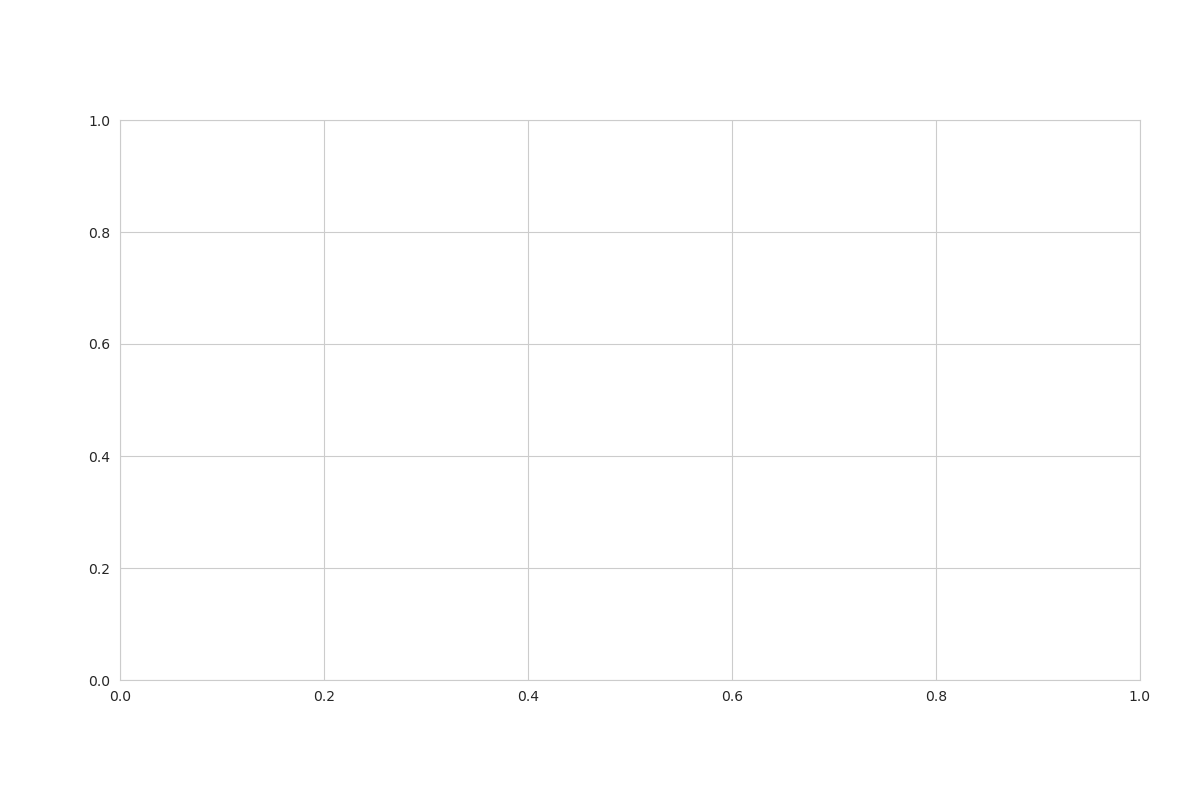

In [19]:
%matplotlib widget

def create_simple_kde_animation(df, score_column='metrics_content_score', 
                              date_column='created_at', window_size=10):
    """
    Simplified animated KDE showing rolling window distributions with consistent scaling
    """
    # Prepare data
    df_clean = df.copy()
    df_clean = df_clean.sort_values(date_column).reset_index(drop=True)
    df_clean = df_clean.dropna(subset=[score_column])

    # Pre-calculate consistent axes limits
    y_max = 3.5
    score_min = df_clean[score_column].min()
    score_max = df_clean[score_column].max()
    score_margin = (score_max - score_min) * 0.15  # 15% margin
    x_min = score_min - score_margin
    x_max = score_max + score_margin
    score_range = np.linspace(x_min, x_max, 100)
    
    total_frames = len(df_clean)
    
    # Create figure with extra padding
    fig, ax = plt.subplots(figsize=(12, 8))
    
    def animate(frame):
        ax.clear()
        
        # Get current window
        start_idx = frame
        end_idx = frame + window_size
        window_data = df_clean.iloc[start_idx:end_idx][score_column]
        
        if len(window_data) >= 3:
            # Calculate actual statistics
            actual_20th = window_data.quantile(0.2)
            mean_val = window_data.mean()
            std_val = window_data.std()
            
            # Calculate KDE
            kde = stats.gaussian_kde(window_data)
            kde_density = kde(score_range)
            
            # Calculate normal distribution
            normal_density = stats.norm.pdf(score_range, mean_val, std_val)
            normal_20th = stats.norm.ppf(0.2, mean_val, std_val)
            
            # Plot KDE curve and threshold
            ax.plot(score_range, kde_density, color='steelblue', linewidth=3, 
                    label='Actual KDE', alpha=0.8)
            ax.fill_between(score_range, kde_density, alpha=0.3, color='steelblue')
            ax.axvline(actual_20th, color='steelblue', linestyle='-', linewidth=2, 
                       label=f'Actual 20th: {actual_20th:.3f}')

            # Plot Normal curve and threshold
            ax.plot(score_range, normal_density, color='red', linewidth=2, 
                    linestyle='--', label='Normal Approximation', alpha=0.8)
            ax.fill_between(score_range, normal_density, alpha=0.2, color='red')
            ax.axvline(normal_20th, color='red', linestyle='--', linewidth=2,
                       label=f'Normal 20th: {normal_20th:.3f}')

            # Add rug plot at consistent position
            rug_y = np.full(len(window_data), -y_max * 0.03)
            ax.scatter(window_data, rug_y, alpha=0.7, color='darkblue', s=30, zorder=5)
            
            ax.set_title(f'Content Score Distribution (Rolling Window)\nFrame: {frame}/{total_frames}', fontsize=14, pad=30)
            
            ax.legend(loc='upper right')

        else:
            ax.text(0.5, 0.5, f'Insufficient data (n={len(window_data)})', 
                   transform=ax.transAxes, ha='center', va='center')
        
        # CONSISTENT AXES - no more jumping around!
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(-y_max * 0.05, y_max)
        ax.set_xlabel('Content Score', fontsize=12)
        ax.set_ylabel('Probability Density', fontsize=12)
        ax.grid(True, alpha=0.3)
        
    # Create animation
    ani = animation.FuncAnimation(fig, animate, frames=total_frames, 
                                interval=200, repeat=True, cache_frame_data=True)
    
    # Add padding around the plot to prevent title cutoff
    plt.subplots_adjust(top=0.85, bottom=0.15, left=0.1, right=0.95)
    
    plt.show()
    
    return ani

ani = create_simple_kde_animation(df, window_size=20)

In [20]:
ani.save("../results/normal_cost.gif", writer='pillow', fps=15)